# ATAG Waypoint 2050 (3rd edition, light) - Scenario S2

Lightweight version of the 3rd edition S2 (technology-centric scenario). The seven
individual biomass SAF pathways (HEFA/ATJ/FT) are collapsed into a single
**generic biofuel**: its quantity is the sum of the pathway quantities and its
CO2 emission factor is the quantity-weighted mean of the pathway factors. Electrofuel,
fossil kerosene, hydrogen and electric are unchanged, so total emissions match the
full 3rd edition S2.

The generic biofuel energy file (`data_inputs/s2_energy.yaml`) is produced with
`aeromaps.utils.energy_aggregation.aggregate_carriers_to_generic`.

## (Re)generate the generic-biofuel energy file

Run this cell to rebuild `data_inputs/s2_energy.yaml` from the full 3rd edition
pathways. It is idempotent and can be skipped if the file already exists.

In [1]:
from aeromaps.utils.energy_aggregation import aggregate_carriers_to_generic

BIOMASS_PATHWAYS = [
    "hefa_oil_crops_trees",
    "atj_cellulosic_cover_crops",
    "hefa_waste_residue_lipids",
    "atj_agricultural_residues",
    "ft_woody_biomass",
    "ft_municipal_solid_waste",
    "atj_waste_gas",
]

aggregate_carriers_to_generic(
    energy_carriers_file="../3rd_edition_full/data_inputs/s2_energy.yaml",
    carriers_to_merge=BIOMASS_PATHWAYS,
    generic_name="generic_biofuel",
    output_file="data_inputs/s2_energy.yaml",
    resource_name="generic_biomass",
)
print("Generated data_inputs/s2_energy.yaml")

Generated data_inputs/s2_energy.yaml

## Load and compute

In [2]:
%matplotlib widget
from aeromaps import create_process

process = create_process(configuration_file="config_files/config_s2.yaml")
process.compute()
process.write_json()

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:220: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:220: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:220: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:140: UserWarning: 
[Interpolation Model: electrofuel_co2_emission_factor_without_resource Warning]
The first reference year (2025) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:140: UserWarning: 
[Interpolation Model: electrofuel_mean_mfsp_without_resource Warning]
The first reference year (2025) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(


## Results

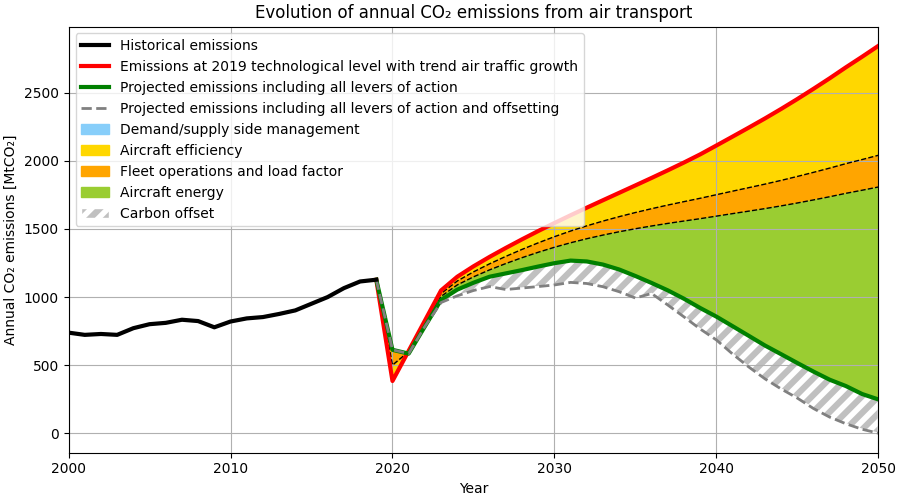

In [3]:
process.plot("air_transport_co2_emissions")

interactive(children=(Dropdown(description='Aircraft Type:', options=('dropin_fuel', 'electric', 'hydrogen', '…

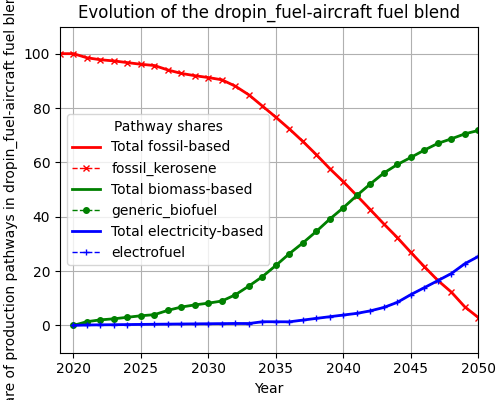

In [4]:
process.plot("fuel_shares")

interactive(children=(SelectMultiple(description='Energy carrier:', index=(0,), options=(('All pathways', 'all…

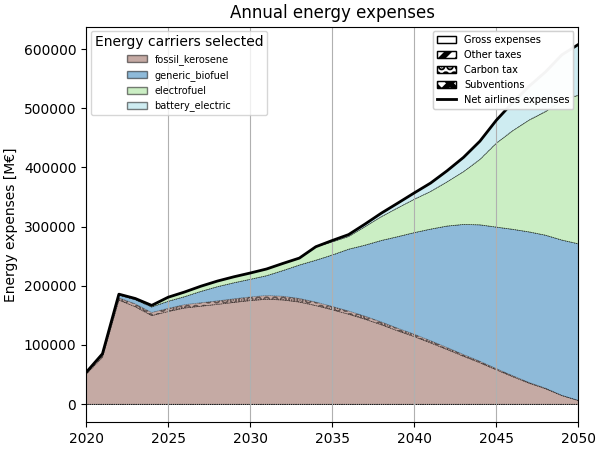

In [5]:
process.plot("energy_expenses")